<iframe width="1000" height="600" src="https://miro.com/app/live-embed/uXjVLR5jtcE=/?moveToViewport=239,-558,309,1823&embedId=408910727659" frameborder="0" scrolling="no" allow="fullscreen; clipboard-read; clipboard-write" allowfullscreen></iframe>

## Data Processing

Read student records from the CSV file, perform data removing and type conversion, and then organise the data into shuffled sublists

### Create Empty List
Create an empty list, `datamain`, to hold the processed records from the CSV file.

### Reading and Processing the CSV File
Reads from the file and processes each line.

```python
with open('records.csv', mode='r') as file:
    for line in file:
        datamain.append(line.replace('G-', '').strip().split(','))
```
* **File Reading**: Opens the CSV file in read mode
* **Data Removing**: For each line, the code:
  * Removes the `'G-'`
  * Strips any leading or trailing whitespace
  * Splits the line by commas and appends the result to `datamain`

### Header Remove
The header is removed from the dataset

```python
del datamain[0]
```

### Data Conversion and Simplification
Iterates over each list in `datamain` to convert data types

```python
for list in datamain:
    list[0] = int(list[0])
    list[5] = float(list[5])
```

* The first element (Tutorial Group) is converted to an integer
* The sixth element (CGPA) is converted to a float

### Data Sorting
The data is sorted based on Tutorial Group

```python
datamain.sort()
```

### Data Grouping
The sorted data is divided into sublists of $50$ entries each

```python
sorted_list = [datamain[x:x + 50] for x in range(0, len(datamain), 50)]
```

### Randomising
Each sublist is shuffled to randomise the order of entries

```python
for sub_list in sorted_list:
    random.shuffle(sub_list)
```

## Data Structure: `datamain`
```python
datamain = [
  [<Tutorial Group>, <Student ID>, <School>, <Name>, <Gender>, <CGPA>],
  [<Tutorial Group>, <Student ID>, <School>, <Name>, <Gender>, <CGPA>],
  ...,
  [<Tutorial Group>, <Student ID>, <School>, <Name>, <Gender>, <CGPA>]
]
```

`<Tutorial Group>`
* **Type**: Integer
* The tutorial group the student belongs to.

`<Student ID>`
* **Type**: String
* Student ID of the student.

`<School>`
* **Type**: String
* The name of the school the student attends.

`<Name>`
* **Type**: String
* The name of the student.

`<Gender>`
* **Type**: String
* The gender of the student.

`<CGPA>`
* **Type**: Float
* The CGPA of the student.

In [102]:
import random
import statistics

shuffle_alternative = True
datamain = []                                                                   # Initialize an empty list to hold the main data from the CSV
with open('records.csv', mode = 'r') as file:                                   # Read the CSV file and process each line
    for line in file:
        datamain.append(line.replace('G-', '').strip().split(','))              # Remove the prefix 'G-' from entries, strip whitespace, and split by commas
del datamain[0]                                                                 # Remove the header row
for list in datamain:
    list[0] = int(list[0])                                                      # Convert first element (ID) to integer
    list[5] = float(list[5])                                                    # Convert sixth element (CGPA) to float
datamain.sort()                                                                 # Sort the data based on the first element (ID)
sorted_list = [datamain[x:x+50] for x in range(0, len(datamain), 50)]           # Split the sorted data into sublists

for sub_list in sorted_list:
    if shuffle_alternative == False:
        random.shuffle(sub_list)                                                # Shuffle each group for randomization if not alternative
    else:
        tut_group_mean = statistics.mean([i[5] for i in sub_list])              # Shuffle each group by descending difference of CGPA from global mean CGPA
        sub_list.sort(reverse = True, key=lambda x: abs(x[5] - tut_group_mean))

## `control_maker( )`
Split the list into smaller groups based on a specified group size.

### Parameters: `sorted_list`, `grp_size`
`sorted_list`
- **Type:** List
- A list of lists, where each sublist contains elements that need to be grouped.

  ```python
  sorted_list = [
    [
      [<Tutorial Group 1>, <School>, <Name>, <Gender>, <CGPA>],
      [<Tutorial Group 1>, <School>, <Name>, <Gender>, <CGPA>],
      ...,
      [<Tutorial Group 1>, <School>, <Name>, <Gender>, <CGPA>]
    ]
    [
      [<Tutorial Group 2>, <School>, <Name>, <Gender>, <CGPA>],
      ...,
      [<Tutorial Group 2>, <School>, <Name>, <Gender>, <CGPA>]
    ]
    ...,
    [
      [<Tutorial Group 120>, <School>, <Name>, <Gender>, <CGPA>],
      ...,
      [<Tutorial Group 120>, <School>, <Name>, <Gender>, <CGPA>]
    ]
  ]
  ```

`grp_size`
- **Type:** integer
- The desired size of each smaller group.

### Create empty list
Creating an empty list called `control_list` to store the resulting groups.

### Looping Through the List
Looping through each sublist in `sorted_list`, referred to as `tut_group`.

### Grouping Elements
For each `tut_group`, it constructs new lists by spliting the elements in `tut_group` into smaller groups of the `grp_size`.

'''python
control_list.append([tut_group[x:x+grp_size] for x in range(0, len(tut_group), grp_size)])
'''

### Appending to Control List
The grouped sublists are appended to the `control_list`

### Return Statement
The function returns the completed `control_list`, containing the groups.

### Returns
The function returns a list of lists, where each inner list contains groups of elements splited according to the specified `grp_size`.

```python
control_list = [
  [
    [
      [<Tutorial Group 1>, <School>, <Name>, <Gender>, <CGPA>],
      [<Tutorial Group 1>, <School>, <Name>, <Gender>, <CGPA>],
      ...,
      [<Tutorial Group 1>, <School>, <Name>, <Gender>, <CGPA>]
    ]
    
    ...,
    [
      [<Tutorial Group 1>, <School>, <Name>, <Gender>, <CGPA>],
      ...,
      [<Tutorial Group 1>, <School>, <Name>, <Gender>, <CGPA>]
    ]
  ],
  ...,
  [
    [
      [<Tutorial Group 120>, <School>, <Name>, <Gender>, <CGPA>],
      [<Tutorial Group 120>, <School>, <Name>, <Gender>, <CGPA>],
      ...,
      [<Tutorial Group 120>, <School>, <Name>, <Gender>, <CGPA>]
    ]
    
    ...,
    [
      [<Tutorial Group 120>, <School>, <Name>, <Gender>, <CGPA>],
      ...,
      [<Tutorial Group 120>, <School>, <Name>, <Gender>, <CGPA>]
    ]
  ],
]

```

In [103]:
# Function to organize sorted list into groups based on given group size
def control_maker(sorted_list, grp_size):
    control_list = []
    for tut_group in sorted_list:
        control_list.append([tut_group[x:x+grp_size] for x in range(0, len(tut_group), grp_size)])
    return control_list

## `grade( )`
Evaluates how the addition of a particular student affects gender balance, school diversity and average CGPA of a group. It computes three scores:

* `gend_score` - gender score
* `sch__div_score` - school diversity score
* `cgpa_score` - Average CGPA score

which are added and returned

### Parameter: `info`

The `info` parameter is a list that contains three specific sublists, each containing different aspects of student information. The structure of `info` is as follows:

```python
info = [
  [<female_count>, <male_count>, <is_male>],
  [['school1', 'school2', ...], 'new_school'],
  [<old_mean_group_cgpa>, <new_mean_group_cgpa>, <mean_global_cgpa>]
]
```

#### Gender Information

```[<female_count>, <male_count>, <is_male>]```

```<female_count>```
* **Type**: Integer
* Total number of female students currently in the group.

```<male_count>```
* **Type**: Integer
* Total number of male students currently in the group.

```<is_male>```
* **Type**: Boolean
* Specifies the gender of the student to be added to the group. A value of True indicates that the new student is male, while False indicates that the student is female.

#### School Information

```[['school1', 'school2', ...], 'new_school']```

```['school1', 'school2', ...]```
* **Type**: List of Strings
* The names of schools that are already represented by students in the group.

```'new_school'```
* **Type**: String
* The school of the student being added.

#### CGPA Information

```[<old_mean_group_cgpa>, <new_mean_group_cgpa>, <mean_global_cgpa>]```

```<old_mean_group_cgpa>```
* **Type**: Float
* The mean CGPA of the group before adding the new student.

```<new_mean_group_cgpa>```
* **Type**: Float
* The mean CGPA of the group after the new student has been added.

```<mean_global_cgpa>```
* **Type**: Float
* The mean CGPA of all students.

### Scoring Formula
$$\text{Total Score} = \text{Gender Diversity Score} + \text{School Diversity Score} + \text{CGPA Score}$$

### Scoring Criteria

#### Gender Diversity Score
##### Calculate Gender Difference
Calculated using the absolute difference between the number of males and females in the group:

```python
gender_difference = abs(info[0][0] - info[0][1])
```

##### Compute `gend_score`
The `gend_score` is computed based on the gender difference and the gender of the student being added:

* If a minority gender is added, the score is adjusted upwards, calculated as follows:

$$gend\_score = \frac{1}{1 + e^{-gender\_difference}}$$

* if a majority gender is added, the score is adjusted downwards, calculated as follows:

$$gend\_score = \frac{1}{1 + e^{gender\_difference}}$$

* if both genders are equal, the score is set to the neutral value of $0.5$

#### School Diversity Score
##### Count Repeated Schools
Counts how many times the school of the new student appears in the list of existing schools
```python
repeated_schools = info[1][0].count(info[1][1])
```

##### Compute School Diversity Score
Calculated using a logarithmic function that decreases with an increasing count of repeated schools, calculated as follows: $$sch\_div\_score = e^{-repeated\_schools}$$

#### CGPA Score
##### Calculate Differences
The absolute difference between the previous CGPA and the target CGPA

```python
old_difference = abs(info[2][0] - info[2][2])
```

The absolute difference between the current CGPA and the target CGPA

```python
new_difference = abs(info[2][1] - info[2][2])
```

The absolute change between the old and new differences

```python
change_in_difference = abs(old_difference - new_difference)
```

##### Compute CGPA Score
Calculated based on the comparison of old and new differences:

* If the old difference is greater then the new difference (indicating improvement), the score is calculated as:

$$cgpa\_score = \frac{1}{1 + e^{-change\_in\_difference}}$$

* If the old difference is less than the new difference (indicated decline), the score is calculated as:

$$cgpa\_score = \frac{1}{1 + e^{change\_in\_difference}}$$

* If both differences are equal (indicating no change), the score is set to a neutral value of $0.5$

In [104]:
def grade(info):

    '''
    Calculates the difference in genders in a group if a particular student were to be added.
    Scoring system for the gend_score operates based on a Sigmoid Function.
    The neutral case where both males and females are of the same quantity before the student is added is represented by a score of 0.5.
    The score is lowered from 0.5 if a gender that is in the majority is to be added to the group.
    The score is increased from 0.5 if a gender that is in the minority is to be added to the group.
    '''
    # Calculate the gender difference between males and females in the group
    gender_difference = abs(info[0][0] - info[0][1])

    # Calculate gend_score using sigmoid function based on gender balance
    if (info[0][0] > info[0][1] and info[0][2] == True) or (info[0][0] < info[0][1] and info[0][2] == False):
      gend_score = 1 / (1 + 2.718281828459045 ** -(gender_difference))
    elif (info[0][0] < info[0][1] and info[0][2] == True) or (info[0][0] > info[0][1] and info[0][2] == False):
      gend_score = 1 / (1 + 2.718281828459045 ** (gender_difference))
    else:
      gend_score = 0.5


    '''
    Calculates the amount of times the school of the new student to be added already appears.
    Scoring is based on a logarithmic curve with steep drop when school is repeated.
    '''
    repeated_schools = info[1][0].count(info[1][1])
    # Calculate school diversity score
    sch_div_score = 2.718281828459045 ** -(repeated_schools)


    '''
    Calculates the difference in genders in a group if a particular student were to be added.
    Scoring system for the cgpa_score operates based on a Sigmoid Function.
    The neutral case where both males and females are of the same quantity before the student is added is represented by a score of 0.5.
    The score is lowered from 0.5 if a gender that is in the majority is to be added to the group.
    The score is increased from 0.5 if a gender that is in the minority is to be added to the group.
    '''

    # Calculate CGPA score
    old_difference = abs(info[2][0] - info[2][2])
    new_difference = abs(info[2][1] - info[2][2])
    change_in_difference = abs(old_difference - new_difference)

    if old_difference > new_difference:
      cgpa_score = 1 / (1 + 2.718281828459045 ** -(change_in_difference))
    elif old_difference < new_difference:
      cgpa_score = 1 / (1 + 2.718281828459045 ** (change_in_difference))
    else:
      cgpa_score = 0.5
 # Return the sum of all three scores
    return gend_score + sch_div_score + cgpa_score

## `extract(a_list, index)`
Helper function to extract a specific index from a list of list and returns the extracted list at the given index from each sublist

### Parameters
#### `a_list`
- **Type**: List
- List of lists that containing sublists

  ```python
  a_list = [
    [<Tutorial Group>, <School>, <Name>, <Gender>, <CGPA>],
    [<Tutorial Group>, <School>, <Name>, <Gender>, <CGPA>],
    ...,
    [<Tutorial Group>, <School>, <Name>, <Gender>, <CGPA>]
  ]
  ```

####  `index`
- **Type**: integer
- The index of the list to extract from each sublist

### Returns
The list extracted from the specified index of each sublist in `a_list`. If the extracted value is empty, it returns `[0]` as a default value

In [105]:
# Helper function to extract a specific index from a list of lists
def extract(a_list, index):
    extracted_list = [item[index] for item in a_list]
    if extracted_list == []:
        extracted_list = [0]
    return extracted_list

## `sorter(student_list, grp_size)`
Sort students into groups based on the custom grading function. Ensures the diversity of each groups.

### Parameters
#### `student_list`
- **Type**:  List
- A list of lists of lists that contains the students unique information.

  ```python
  student_list = [
    [
      [<Tutorial Group 1>, <School>, <Name>, <Gender>, <CGPA>],
      [<Tutorial Group 1>, <School>, <Name>, <Gender>, <CGPA>],
      ...,
      [<Tutorial Group 1>, <School>, <Name>, <Gender>, <CGPA>]
    ]
    [
      [<Tutorial Group 2>, <School>, <Name>, <Gender>, <CGPA>],
      ...,
      [<Tutorial Group 2>, <School>, <Name>, <Gender>, <CGPA>]
    ]
    ...,
    [
      [<Tutorial Group 120>, <School>, <Name>, <Gender>, <CGPA>],
      ...,
      [<Tutorial Group 120>, <School>, <Name>, <Gender>, <CGPA>]
    ]
  ]
  ```

#### `grp_size`
- **Type:** integer
- The desired size of each smaller group.

### Create Empty List
A list of lists `final_list` is created to hold the students groups. The structure is automatically adjusted if the group size is not evenly divided by 50.

```python
final_list = [
  [
    [], [], ..., []
  ],
  [
    [], [], ..., []
  ],
  ...,
  [
    [], [], ..., []
  ]
]
```

### Looping Through the Tutorial Group
For each tutorial group in `student_list`, the global CGPA of the group is calculated.

### Evaluating Group Assignments
For each student in the tutorial group, a grade will be assigned to that student's fitness into each group using the `grade( )` function

### Assigning Studnet to Group
Each student is added to the group with the highest fitness grade and ensuring that there are no groups exceeds the required `grp_size`

In [106]:
# Function to sort students into groups based on custom grading function
def sorter(student_list, grp_size):
    final_list = [[[] for x in range(50 // grp_size + (50 % grp_size > 0))] for x in range(120)]
    for tut_group in student_list:
        global_cgpa = sum(extract(tut_group, 5)) / 50
        for student in tut_group:
            is_male = student[4] == 'Male'
            school = student[2]
            cgpa = student[5]
            grade_list = []
            tut_index = student[0] - 1
            for project_group in final_list[tut_index]:
                if len(project_group) == grp_size:
                    grade_list.append(-1)
                    continue

                info = [
                    [int(extract(project_group, 4).count('Female')), int(extract(project_group, 4).count('Male')), is_male],
                    [extract(project_group, 2), school],
                    [((sum(extract(project_group, 5))) / (len(extract(project_group, 5)))), ((sum([*extract(project_group, 5), cgpa])) / (len(extract(project_group, 5)) + 1)), global_cgpa]
                ]
                grade_list.append(grade(info))
            final_list[tut_index][grade_list.index(max(grade_list))].append(student)
    return final_list

In [107]:
import statistics

# Set group size and create control list for comparison

def wrangle(group_size_both):

    control_list = control_maker(sorted_list, group_size_both)
    final_sorted_list = sorter(sorted_list, group_size_both)

    # Calculate statistics for comparison of randomized and algorithmic grouping
    control_mean_list = [[statistics.mean(extract(control_sublist, 5)) for control_sublist in control_list[x]] for x in range(120)]
    mean_list = [[statistics.mean(extract(project_group, 5)) for project_group in final_sorted_list[x]] for x in range(120)]
    control_gender_diff_list = [statistics.mean([abs(len(control_sublist) - 2 * extract(control_sublist, 4).count("Male")) for control_sublist in control_list[x]]) for x in range(120)]
    gender_diff_list = [statistics.mean([abs(len(sublist) - 2 * extract(sublist, 4).count("Male")) for sublist in final_sorted_list[x]]) for x in range(120)]
    control_school_dupe_list = [statistics.mean([len(extract(control_sublist, 2)) - len(set(extract(control_sublist, 2))) for control_sublist in control_list[x]]) for x in range(120)]
    school_dupe_list = [statistics.mean([len(extract(sublist, 2)) - len(set(extract(sublist, 2))) for sublist in final_sorted_list[x]]) for x in range(120)]

    # Print summary of improvements using the algorithm for data visualisation
    mean_std_randomised = statistics.mean([statistics.stdev(control_mean_list[x]) for x in range(120)])
    mean_std_algorithm = statistics.mean([statistics.stdev(mean_list[x]) for x in range(120)])
    mean_majority_gender_randomised = statistics.mean(control_gender_diff_list)
    mean_majority_gender_algorithm = statistics.mean(gender_diff_list)
    mean_majority_gender_randomised_corrected = statistics.mean(control_gender_diff_list) - ((group_size_both % 2) > 0)
    mean_majority_gender_algorithm_corrected = statistics.mean(gender_diff_list) - ((group_size_both % 2) > 0)
    mean_duplicate_course_randomised = statistics.mean(control_school_dupe_list)
    mean_duplicate_course_algorithm = statistics.mean(school_dupe_list)
    mean_std_improvement = (mean_std_randomised/mean_std_algorithm - 1) * 100
    mean_majority_gender_improvement = (mean_majority_gender_randomised_corrected/mean_majority_gender_algorithm_corrected - 1) * 100
    mean_duplicate_course_improvement = (mean_duplicate_course_randomised/mean_duplicate_course_algorithm - 1) * 100

    print(f'Mean Standard Deviation for randomised groups: {mean_std_randomised}')
    print(f'Mean Standard Deviation for groups sorted by algorithm: {mean_std_algorithm}')
    print(f'Mean Standard Deviation improvement compared to random sort: {(mean_std_randomised/mean_std_algorithm - 1) * 100}%' + '\n')
    print(f'Mean Majority Gender Excess for randomised groups: {mean_majority_gender_randomised}')
    print(f'Mean Majority Gender Excess for groups sorted by algorithm: {mean_majority_gender_algorithm}')
    print(f'Mean Majority Gender Excess for randomised groups (Corrected for cases where Group Size odd): {mean_majority_gender_randomised_corrected}')
    print(f'Mean Majority Gender Excess for groups sorted by algorithm (Corrected for cases where Group Size odd): {mean_majority_gender_algorithm_corrected}')
    print(f'Mean Majority Gender Excess improvement compared to random sort: {(mean_majority_gender_randomised_corrected/mean_majority_gender_algorithm_corrected - 1) * 100}%' + '\n')
    print(f'Mean Duplicate Courses for randomised groups: {mean_duplicate_course_randomised}')
    print(f'Mean Duplicate Courses for groups sorted by algorithm: {mean_duplicate_course_algorithm}')
    print(f'Mean Duplicate Courses improvement compared to random sort: {(mean_duplicate_course_randomised/mean_duplicate_course_algorithm - 1) * 100}%' + '\n')

    return [mean_std_improvement, mean_majority_gender_improvement, mean_duplicate_course_improvement, final_sorted_list]

final_sorted_list = wrangle(6)[3]

Mean Standard Deviation for randomised groups: 0.04912879204818382
Mean Standard Deviation for groups sorted by algorithm: 0.022050258358527
Mean Standard Deviation improvement compared to random sort: 122.80370256607607%

Mean Majority Gender Excess for randomised groups: 1.8203703703703704
Mean Majority Gender Excess for groups sorted by algorithm: 0.6981481481481482
Mean Majority Gender Excess for randomised groups (Corrected for cases where Group Size odd): 1.8203703703703704
Mean Majority Gender Excess for groups sorted by algorithm (Corrected for cases where Group Size odd): 0.6981481481481482
Mean Majority Gender Excess improvement compared to random sort: 160.74270557029178%

Mean Duplicate Courses for randomised groups: 0.9907407407407407
Mean Duplicate Courses for groups sorted by algorithm: 0.08703703703703704
Mean Duplicate Courses improvement compared to random sort: 1038.2978723404256%



<img src='images/grpsize5instance.jpg' style="width:800px">

<Axes: xlabel='Group Size', ylabel='Mean Duplicate Courses Improvement (%)'>

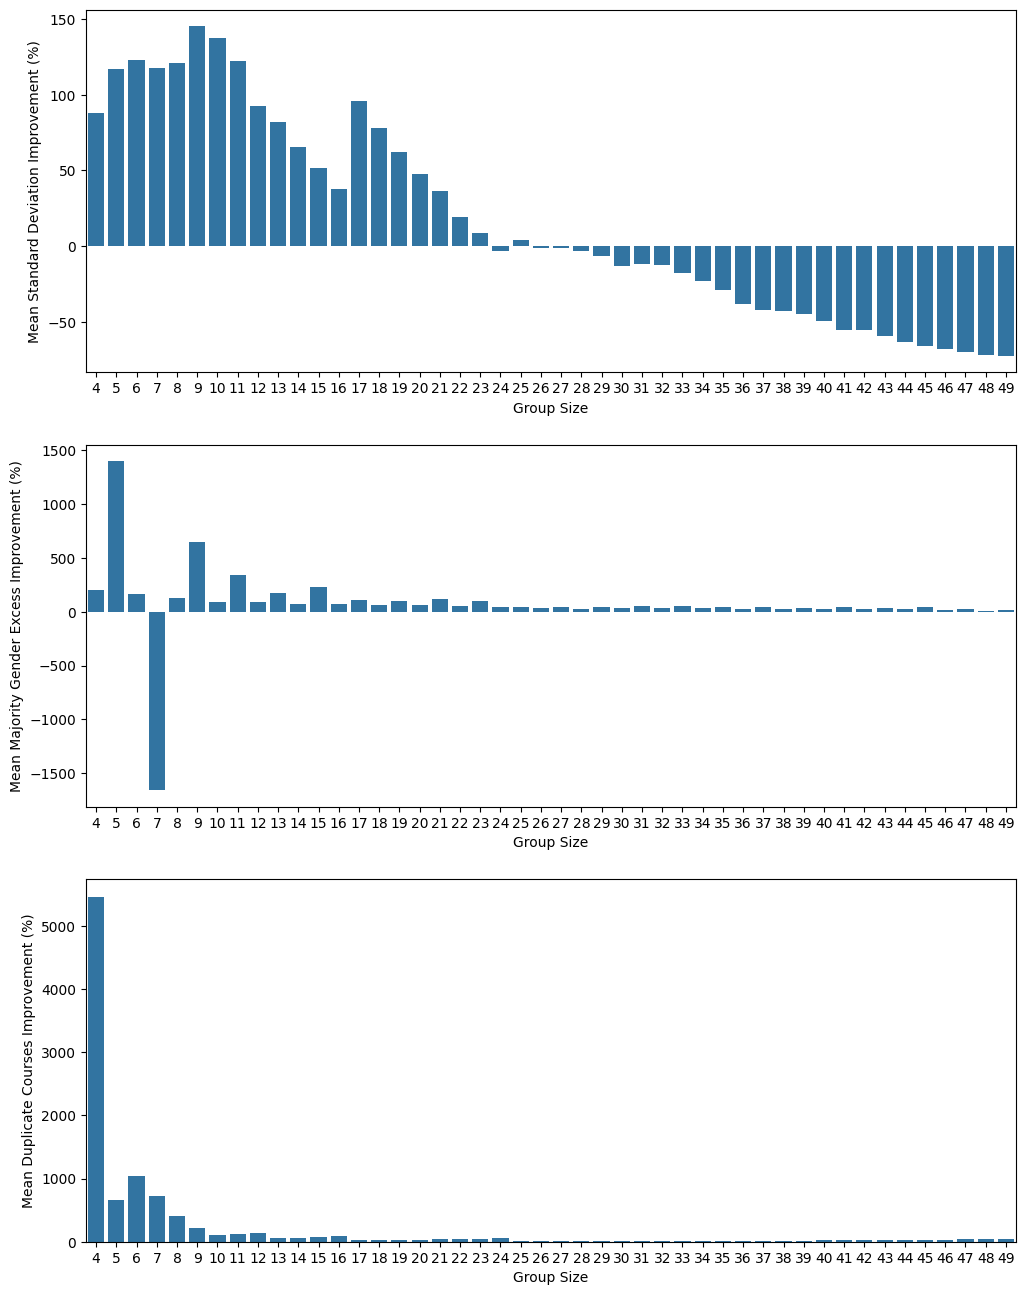

In [108]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import clear_output

def graphmaker(min_val, max_val):
    temp_list = []
    for x in range(min_val, max_val + 1):
        data_instance = [x] + wrangle(x)[:3]
        temp_list.append(data_instance) 
    df=pd.DataFrame(temp_list, columns=['Group Size', 'Mean Standard Deviation Improvement (%)', 'Mean Majority Gender Excess Improvement (%)', 'Mean Duplicate Courses Improvement (%)'])
    df.set_index('Group Size')
    return df

data_df = graphmaker(4,49)
clear_output(wait=False)
fig, axs = plt.subplots(3, 1, figsize=(12,16), gridspec_kw={'height_ratios': [1, 1, 1]})
sns.barplot(data_df, y="Mean Standard Deviation Improvement (%)", x='Group Size', ax= axs[0])
sns.barplot(data_df, y="Mean Majority Gender Excess Improvement (%)", x='Group Size', ax= axs[1])
sns.barplot(data_df, y="Mean Duplicate Courses Improvement (%)", x='Group Size', ax= axs[2])

In [109]:
def record_maker(file_name):
    with open('records.csv', mode='r') as input_file:
        temp_list = input_file.readlines()[1:6001]
        for tut_group in final_sorted_list:
            for sorted_grp in tut_group:
                for student in sorted_grp:
                    temp_list_index = temp_list.index([s for s in temp_list if (student[1] == s.split(',')[1])][0])
                    temp_list[temp_list_index] = temp_list[temp_list_index].replace('\n', '') + f',{tut_group.index(sorted_grp) + 1}\n'

        with open(file_name + '.csv', mode='w') as new_file:
            new_file.write("Tutorial Group,Student ID,School,Name,Gender,CGPA,Group Number in Tutorial Group\n")
            for student in temp_list:
                new_file.write(student)

record_maker('new record')

In [110]:
# Additional code to check size of groups formed, useful in cases where grp size does not divide tutorial group size.

from collections import Counter
with open('new record.csv', mode='r') as input_file:
    input_list = input_file.readlines()
    # Change value to check first x tutorial groups
    for x in range(120):
        temp_list = input_list[x*50 + 1 : x*50 + 51]
        grp_list = []
        for student in temp_list:
            grp_list.append(int(student.strip('\n').split(',')[6]))
        grp_counted = sorted(Counter(grp_list).items())
        print(grp_counted)

[(1, 6), (2, 6), (3, 6), (4, 5), (5, 5), (6, 6), (7, 4), (8, 6), (9, 6)]
[(1, 6), (2, 6), (3, 6), (4, 6), (5, 6), (6, 5), (7, 5), (8, 6), (9, 4)]
[(1, 6), (2, 6), (3, 6), (4, 6), (5, 6), (6, 6), (7, 6), (8, 3), (9, 5)]
[(1, 6), (2, 6), (3, 6), (4, 4), (5, 4), (6, 6), (7, 6), (8, 6), (9, 6)]
[(1, 6), (2, 6), (3, 6), (4, 6), (5, 6), (6, 6), (7, 4), (8, 4), (9, 6)]
[(1, 6), (2, 6), (3, 6), (4, 6), (5, 6), (6, 6), (7, 4), (8, 6), (9, 4)]
[(1, 6), (2, 6), (3, 6), (4, 6), (5, 4), (6, 4), (7, 6), (8, 6), (9, 6)]
[(1, 6), (2, 6), (3, 5), (4, 6), (5, 6), (6, 6), (7, 5), (8, 6), (9, 4)]
[(1, 6), (2, 6), (3, 5), (4, 6), (5, 5), (6, 6), (7, 6), (8, 6), (9, 4)]
[(1, 6), (2, 5), (3, 6), (4, 6), (5, 6), (6, 6), (7, 6), (8, 4), (9, 5)]
[(1, 6), (2, 6), (3, 6), (4, 4), (5, 6), (6, 4), (7, 6), (8, 6), (9, 6)]
[(1, 5), (2, 6), (3, 6), (4, 5), (5, 6), (6, 6), (7, 6), (8, 5), (9, 5)]
[(1, 5), (2, 4), (3, 6), (4, 6), (5, 6), (6, 5), (7, 6), (8, 6), (9, 6)]
[(1, 5), (2, 6), (3, 6), (4, 4), (5, 6), (6, 5), (7